In [1]:
# run setup for notebook
%load_ext rpy2.ipython
%config InlineBackend.figure_format='retina'

In [2]:
# import numpy and matplot lib
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# import tensorflow
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions

/usr/local/lib/python3.11/dist-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
# import gpflow
import gpflow as gf
from gpflow import set_trainable

/usr/local/lib/python3.11/dist-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
# gpflow recommended config
gf.config.set_default_float(np.float64)
gf.config.set_default_jitter(1e-4)
gf.config.set_default_summary_fmt("notebook")

# generate function to convert to float64 for 
# tfp to play nicely with gpflow in 64-bit
f64 = gf.utilities.to_default_float

# Sampling hyperparameters in Gaussian process regression

Build the GPR model.

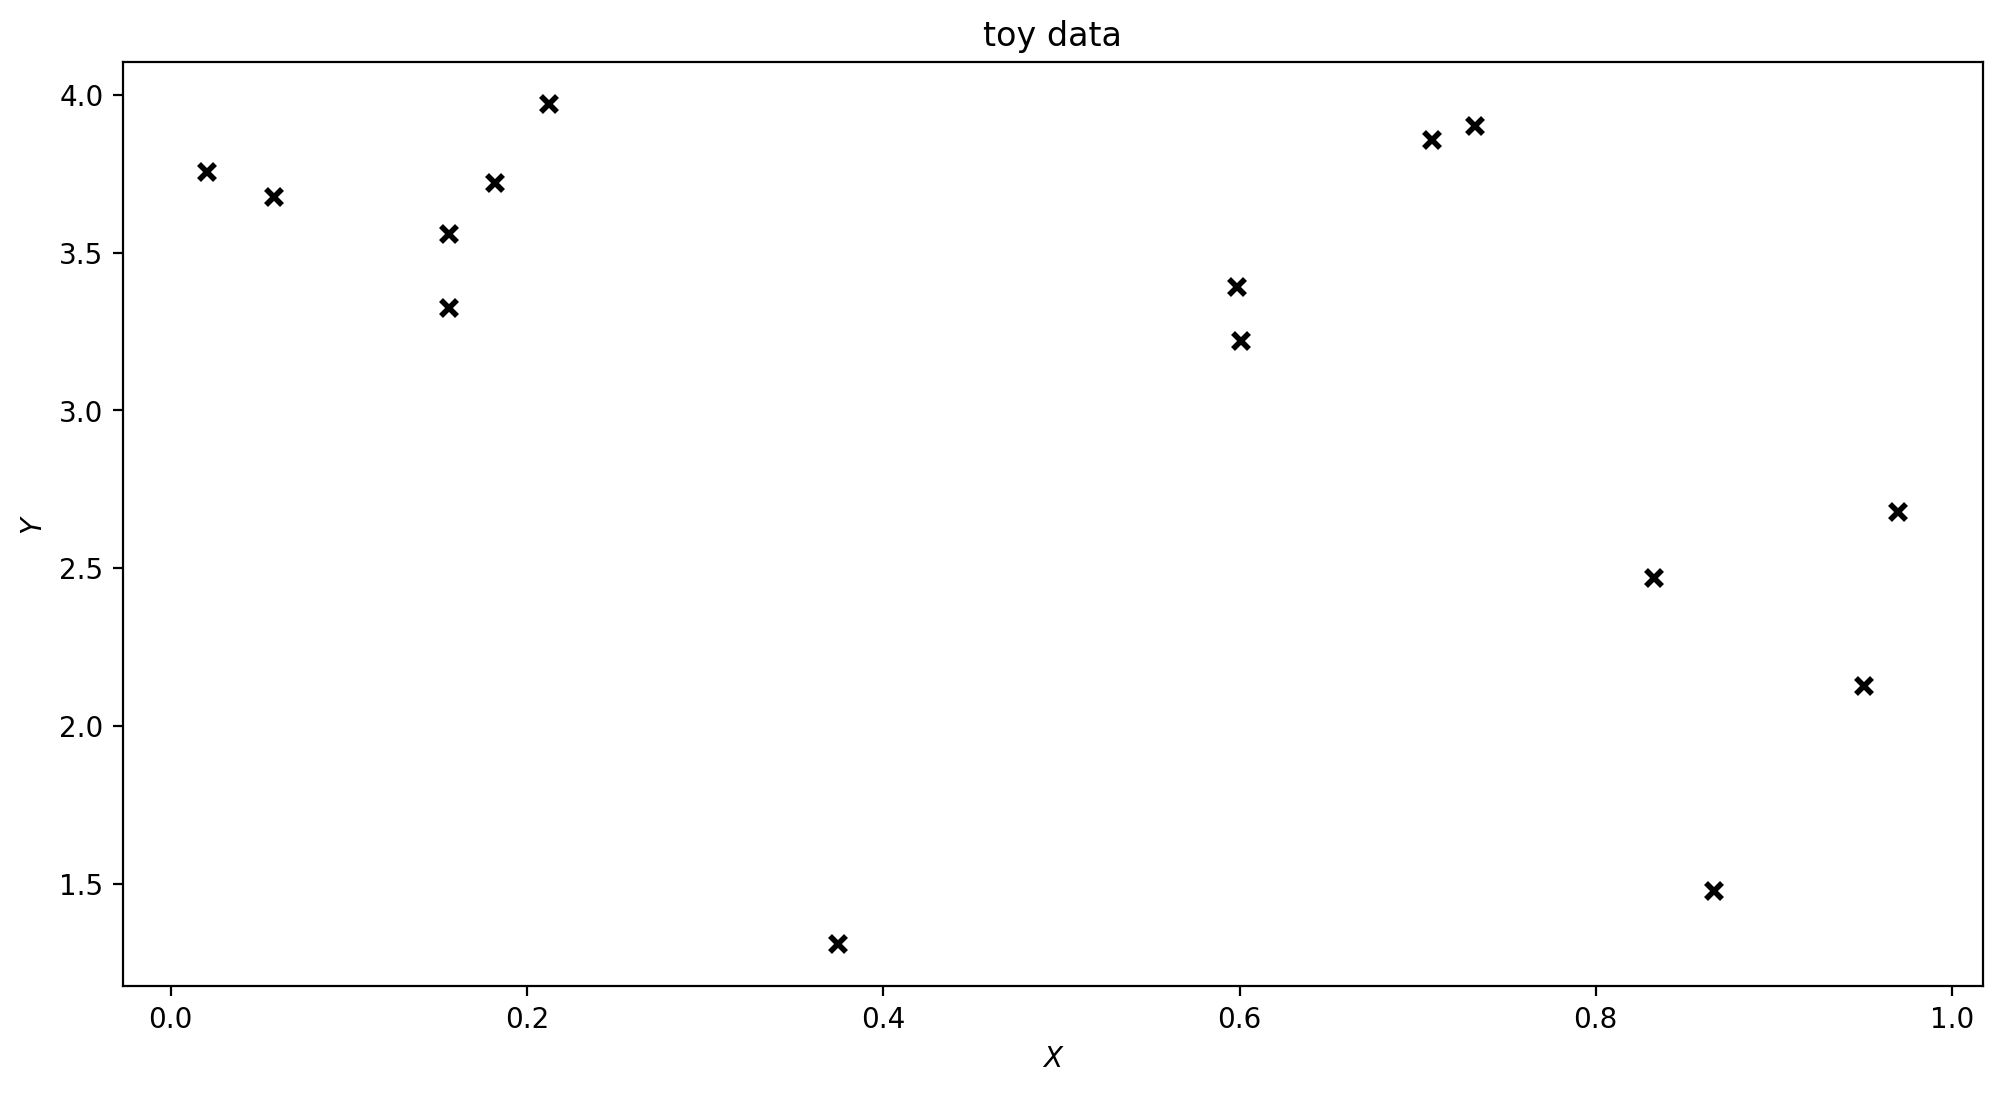

In [6]:
# randomized data
rng = np.random.RandomState(42)

N = 15


def synthetic_data(num: int, rng: np.random.RandomState):
    X = rng.rand(num, 1)
    Y = np.sin(12 * X) + 0.66 * np.cos(25 * X) + rng.randn(num, 1) * 0.1 + 3
    return X, Y


data = (X, Y) = synthetic_data(N, rng)

plt.figure(figsize=(12, 6))
plt.plot(X, Y, "kx", mew=2)
plt.xlabel("$X$")
plt.ylabel("$Y$")
plt.title("toy data")
plt.show()

In [7]:
# fit the model
kernel = gf.kernels.Matern52(lengthscales=0.3)

# the mean_functions.Linear takes A and b where
# y_i = A x_i + b
mean_function = gf.mean_functions.Linear(1.0, 0.0)

model = gf.models.GPR(data, kernel, mean_function, noise_variance=0.01)

Print the model.

In [8]:
model

name,class,transform,prior,trainable,shape,dtype,value
GPR.mean_function.A,Parameter,Identity,,True,"(1, 1)",float64,[[1.]]
GPR.mean_function.b,Parameter,Identity,,True,(),float64,0.0
GPR.kernel.variance,Parameter,Softplus,,True,(),float64,1.0
GPR.kernel.lengthscales,Parameter,Softplus,,True,(),float64,0.30000000000000004
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.009999999999999998


Optimize using maximum likelihood.

In [9]:
# initialize the optimizer
optimizer = gf.optimizers.Scipy()

# minimize
optimizer.minimize(
    
    # a closure that re-evaluates the model, returning the loss to be minimized.
    closure = model.training_loss,
    
    # the list (tuple) of variables to be optimized
    variables = model.trainable_variables,
    
    method = "CG"
)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 11.460240793627467
       x: [-2.493e+00  2.986e-01 -4.095e+00 -7.927e-01  3.378e+00]
     nit: 31
     jac: [-4.414e-07 -7.948e-07 -3.077e-06  5.881e-06  7.112e-07]
    nfev: 58
    njev: 58

Print the optimized model.

In [10]:
model

name,class,transform,prior,trainable,shape,dtype,value
GPR.mean_function.A,Parameter,Identity,,True,"(1, 1)",float64,[[-0.79271744]]
GPR.mean_function.b,Parameter,Identity,,True,(),float64,3.37838
GPR.kernel.variance,Parameter,Softplus,,True,(),float64,0.8535550317390823
GPR.kernel.lengthscales,Parameter,Softplus,,True,(),float64,0.07944876238377
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.016521567744902554


Plot the GP model.

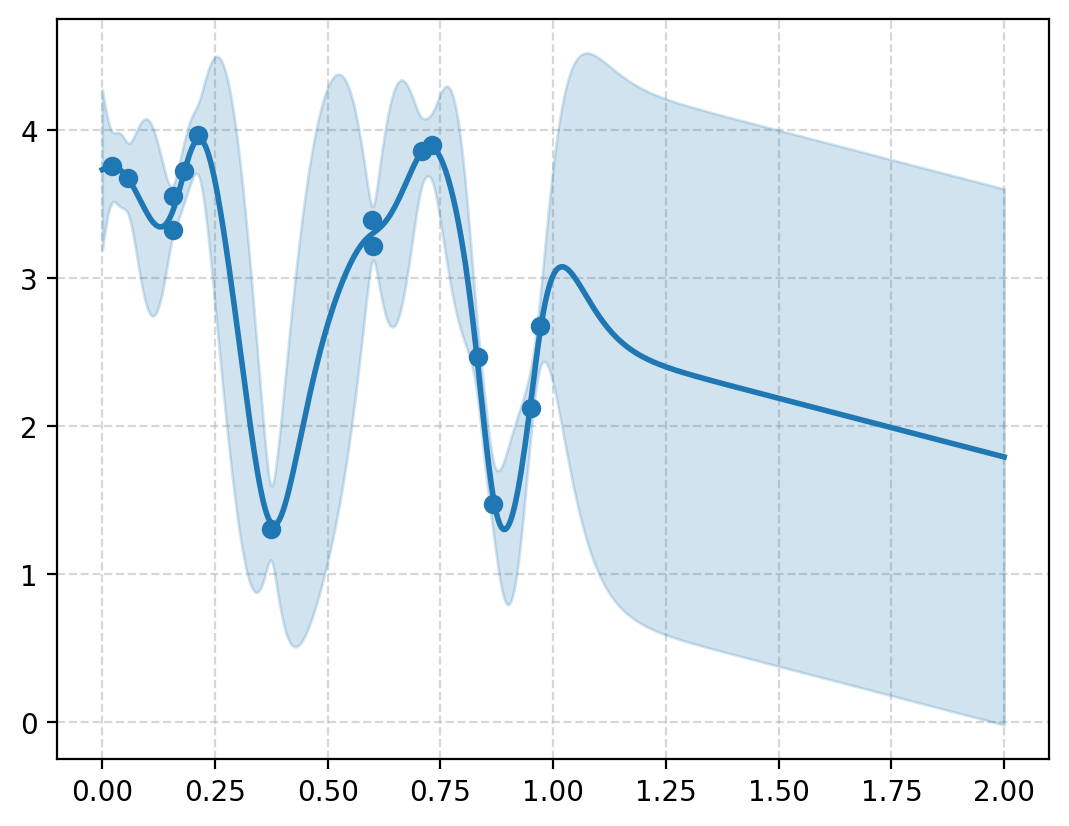

In [11]:
xx = np.linspace(0, 2, 500).reshape(500,1)
mean, var = model.predict_f(xx)

fig, ax = plt.subplots()
ax.scatter(X, Y, zorder = 2)
ax.plot(xx, mean, lw = 2)
ax.fill_between(
    xx[:,0],
    mean[:,0] - 1.96 * np.sqrt(var[:,0]),
    mean[:,0] + 1.96 * np.sqrt(var[:,0]),
    color = 'C0',
    alpha = 0.2,
    zorder = 2
)
ax.grid(True, alpha = 0.5, linestyle = "--")

# Add priors to the hyperparameters

In [12]:
model.kernel.lengthscales.prior = tfd.Gamma(f64(1.0), f64(1.0))
model.kernel.variance.prior     = tfd.Gamma(f64(1.0), f64(1.0))
model.likelihood.variance.prior = tfd.Gamma(f64(1.0), f64(1.0))

model.mean_function.A.prior     = tfd.Normal(f64(0.0), f64(10.0))
model.mean_function.b.prior     = tfd.Normal(f64(0.0), f64(10.0))

In [13]:
# burn in and samples
n_burnin = 500
n_samples = 10000

In [14]:
# initialize the HMC helper
hmc_helper = gf.optimizers.SamplingHelper(
    target_log_prob_fn = model.log_posterior_density,

    # parameters have the priors not the variables
    # model fitting involves trainable_variables
    parameters = model.trainable_parameters
)

In [15]:
hmc = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn = hmc_helper.target_log_prob_fn,
    num_leapfrog_steps = 10,
    step_size = 0.01
)

adaptive_hmc = tfp.mcmc.SimpleStepSizeAdaptation(
    hmc,
    num_adaptation_steps = 10,
    target_accept_prob = f64(0.75),
    adaptation_rate = 0.1
)

In [16]:
@tf.function
def run_chain_fn():
    return tfp.mcmc.sample_chain(
        num_results = n_samples,
        num_burnin_steps = n_burnin,
        current_state = hmc_helper.current_state,
        kernel = adaptive_hmc,
        trace_fn = lambda _, pkr: pkr.inner_results.is_accepted
    )

In addition to returning the chain state, this function supports tracing of auxiliary variables used by the kernel. The traced values are selected by specifying `trace_fn`. By default, all kernel results are traced but in the future the default will be changed to no results being traced, so plan accordingly. See below for some examples of this feature.

`trace_fn` is a callable that takes in the current chain state and the previous kernel results and return a **Tensor** or a nested collection of **Tensor**s that is then traced along with the chain state.

In [17]:
samples, traces = run_chain_fn()

When this function runs are the chains for each of these parameters related? Is this being taken into account?

In [18]:
samples

[<tf.Tensor: shape=(10000,), dtype=float64, numpy=
 array([-2.27524384, -2.38666584, -2.48994665, ..., -2.02350403,
        -1.95691309, -1.48263597])>,
 <tf.Tensor: shape=(10000,), dtype=float64, numpy=
 array([ 0.21752589,  0.05020494, -0.017716  , ...,  2.07080954,
         1.91879575,  1.83700404])>,
 <tf.Tensor: shape=(10000,), dtype=float64, numpy=
 array([-4.2565493 , -4.06522179, -3.64246201, ..., -1.51798485,
        -1.51247646, -1.66387181])>,
 <tf.Tensor: shape=(10000, 1, 1), dtype=float64, numpy=
 array([[[-1.75155379]],
 
        [[-2.27324705]],
 
        [[-2.10192713]],
 
        ...,
 
        [[-4.78614855]],
 
        [[-4.78623958]],
 
        [[-4.84009291]]])>,
 <tf.Tensor: shape=(10000,), dtype=float64, numpy=
 array([4.09543011, 4.02666442, 4.10418429, ..., 4.78653859, 4.68147529,
        4.68557137])>]

In [19]:
traces

<tf.Tensor: shape=(10000,), dtype=bool, numpy=array([ True,  True,  True, ...,  True,  True,  True])>

In [20]:
np.sum(traces)

9992

All the Hamiltonian MCMC sampling takes place in an unconstrained space (where constrained parameters have been mapped via a bijector to an unconstrained space). This makes the optimization, as required in the gradient step, much easier.

In [21]:
parameter_samples = hmc_helper.convert_to_constrained_values(samples)

In [22]:
# get the parameter names that were trained
param_to_name = {
    param: name
    for name, param in gf.utilities.parameter_dict(model).items()
}

In [23]:
param_to_name

{<Parameter: name=identity, dtype=float64, shape=[1, 1], fn="identity", numpy=array([[-4.84009291]])>: '.mean_function.A',
 <Parameter: name=identity, dtype=float64, shape=[], fn="identity", numpy=4.685571365410481>: '.mean_function.b',
 <Parameter: name=softplus, dtype=float64, shape=[], fn="softplus", numpy=1.9848151984871256>: '.kernel.variance',
 <Parameter: name=softplus, dtype=float64, shape=[], fn="softplus", numpy=0.20460348833950073>: '.kernel.lengthscales',
 <Parameter: name=chain_of_shift_of_softplus, dtype=float64, shape=[], fn="chain_of_shift_of_softplus", numpy=0.1734535277178062>: '.likelihood.variance'}

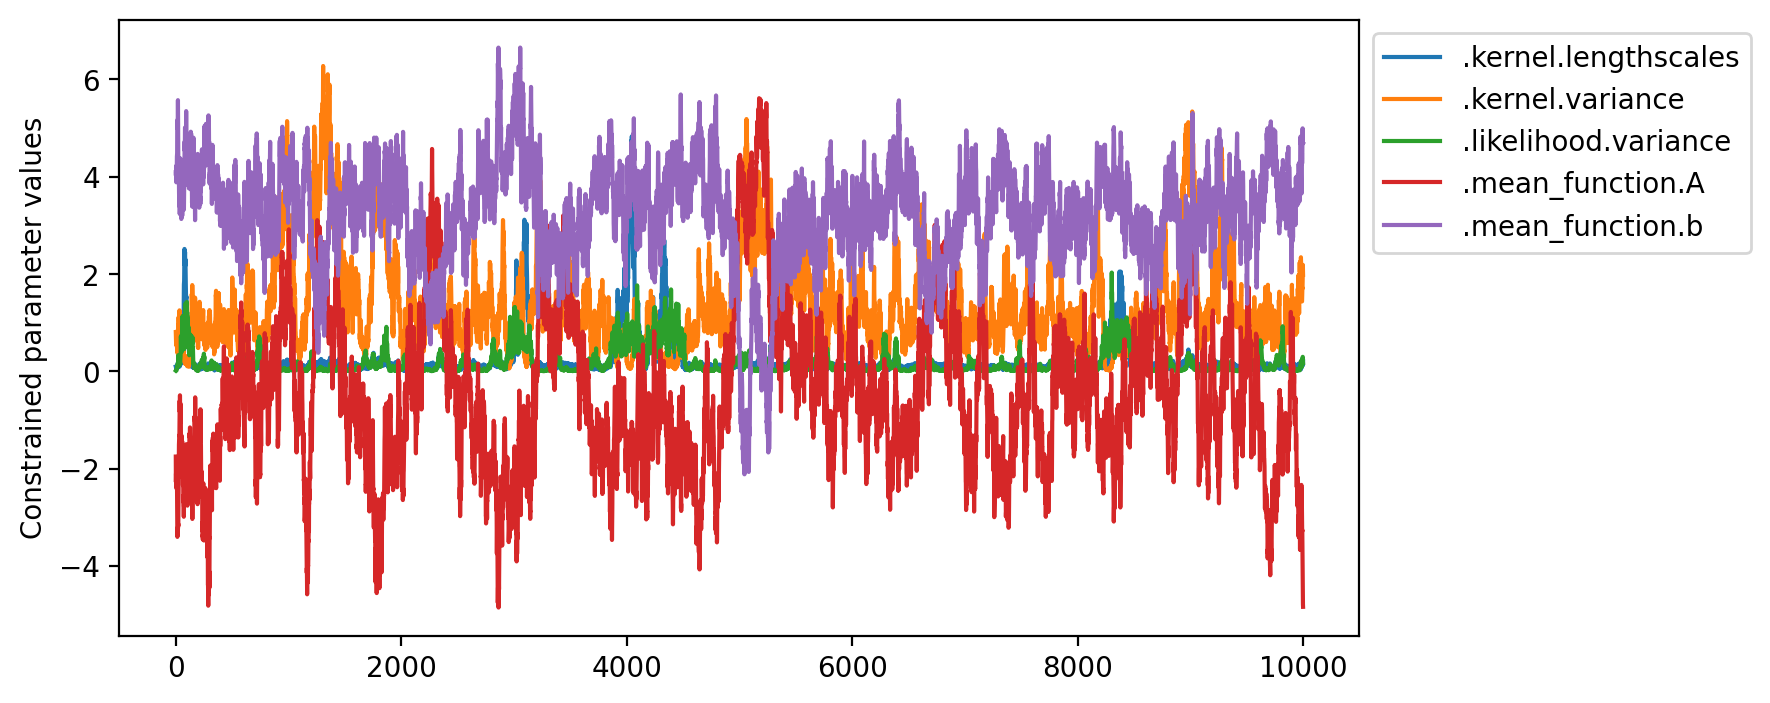

In [24]:
plt.figure(figsize = (8,4))

for val, param in zip(parameter_samples, model.trainable_parameters):
    plt.plot(tf.squeeze(val), label = param_to_name[param])

plt.legend(bbox_to_anchor = (1, 1))
plt.ylabel("Constrained parameter values")
plt.show()

In [25]:
model.trainable_parameters

(<Parameter: name=softplus, dtype=float64, shape=[], fn="softplus", numpy=0.20460348833950073>,
 <Parameter: name=softplus, dtype=float64, shape=[], fn="softplus", numpy=1.9848151984871256>,
 <Parameter: name=chain_of_shift_of_softplus, dtype=float64, shape=[], fn="chain_of_shift_of_softplus", numpy=0.1734535277178062>,
 <Parameter: name=identity, dtype=float64, shape=[1, 1], fn="identity", numpy=array([[-4.84009291]])>,
 <Parameter: name=identity, dtype=float64, shape=[], fn="identity", numpy=4.685571365410481>)

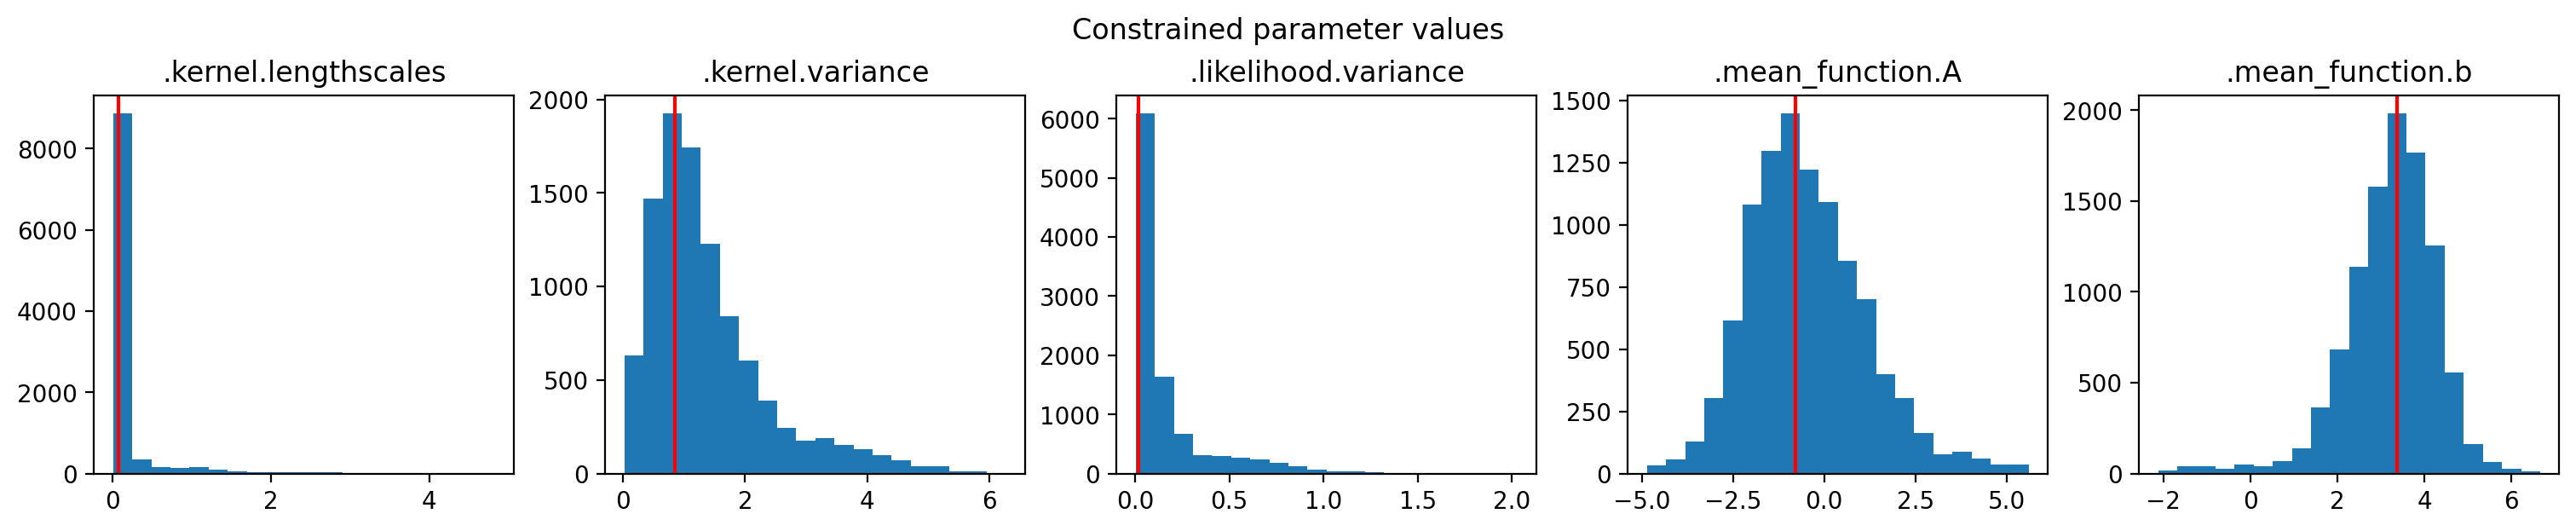

In [26]:
# list of maximum likelihood estimates in the correct order
mle = [0.07944876238377, 0.8535550317390823, 0.016521567744902554, -0.79271744, 3.37838]

fig, axes = plt.subplots(
    1, len(param_to_name), figsize=(15, 3), constrained_layout=True
)

for ax, val, param, mle in zip(axes, parameter_samples, model.trainable_parameters, mle):
    ax.hist(np.stack(val).flatten(), bins=20)
    ax.set_title(param_to_name[param])
    ax.axvline(mle, 0, 1, color = 'r')

fig.suptitle("Constrained parameter values")
plt.show()

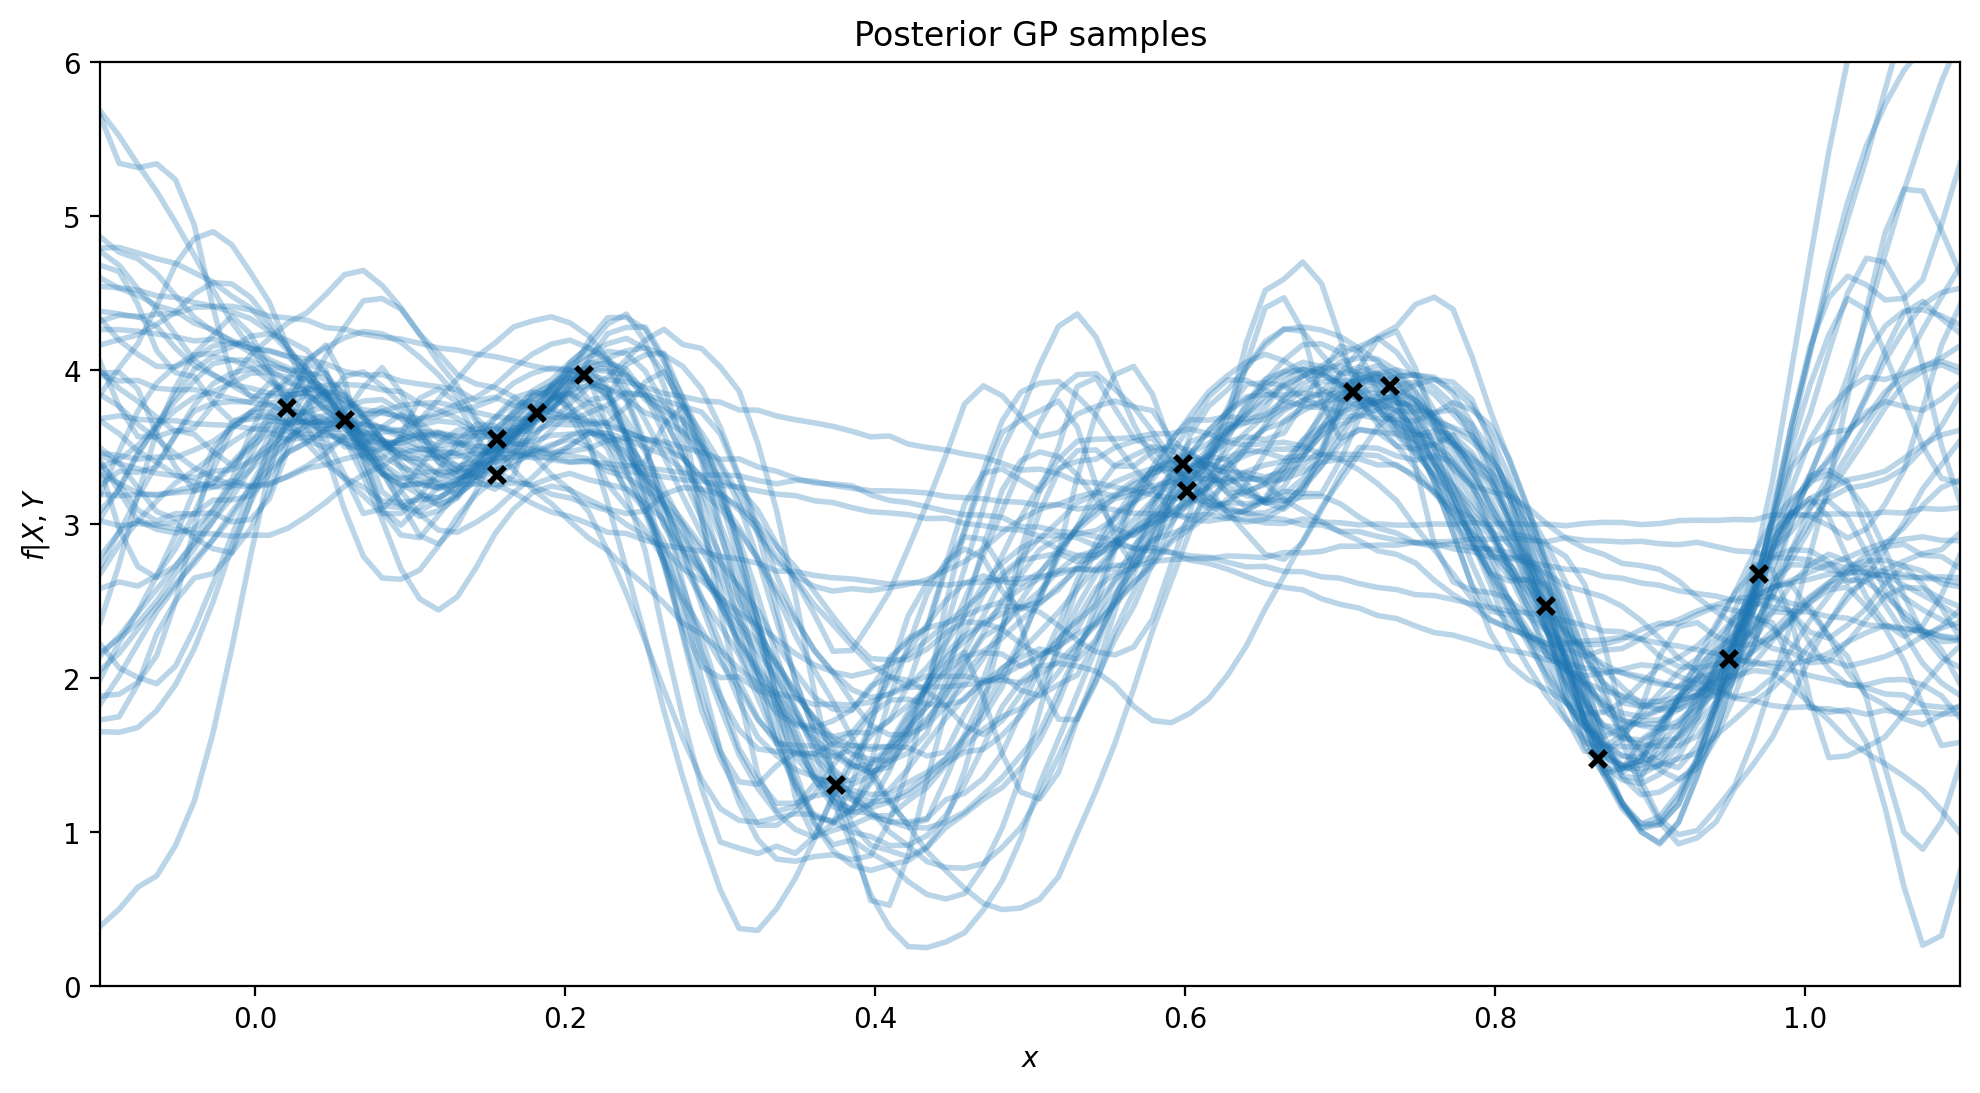

In [27]:
# plot the function posterior
xx = np.linspace(-0.1, 1.1, 100)[:, None]
plt.figure(figsize=(12, 6))

for i in range(0, n_samples, 200):
    for var, var_samples in zip(hmc_helper.current_state, samples):
        var.assign(var_samples[i])
    f = model.predict_f_samples(xx, 1)
    plt.plot(xx, f[0, :, :], "C0", lw=2, alpha=0.3)

plt.plot(X, Y, "kx", mew=2)
plt.xlim(xx.min(), xx.max())
plt.ylim(0, 6)
plt.xlabel("$x$")
plt.ylabel("$f|X,Y$")
plt.title("Posterior GP samples")

plt.show()

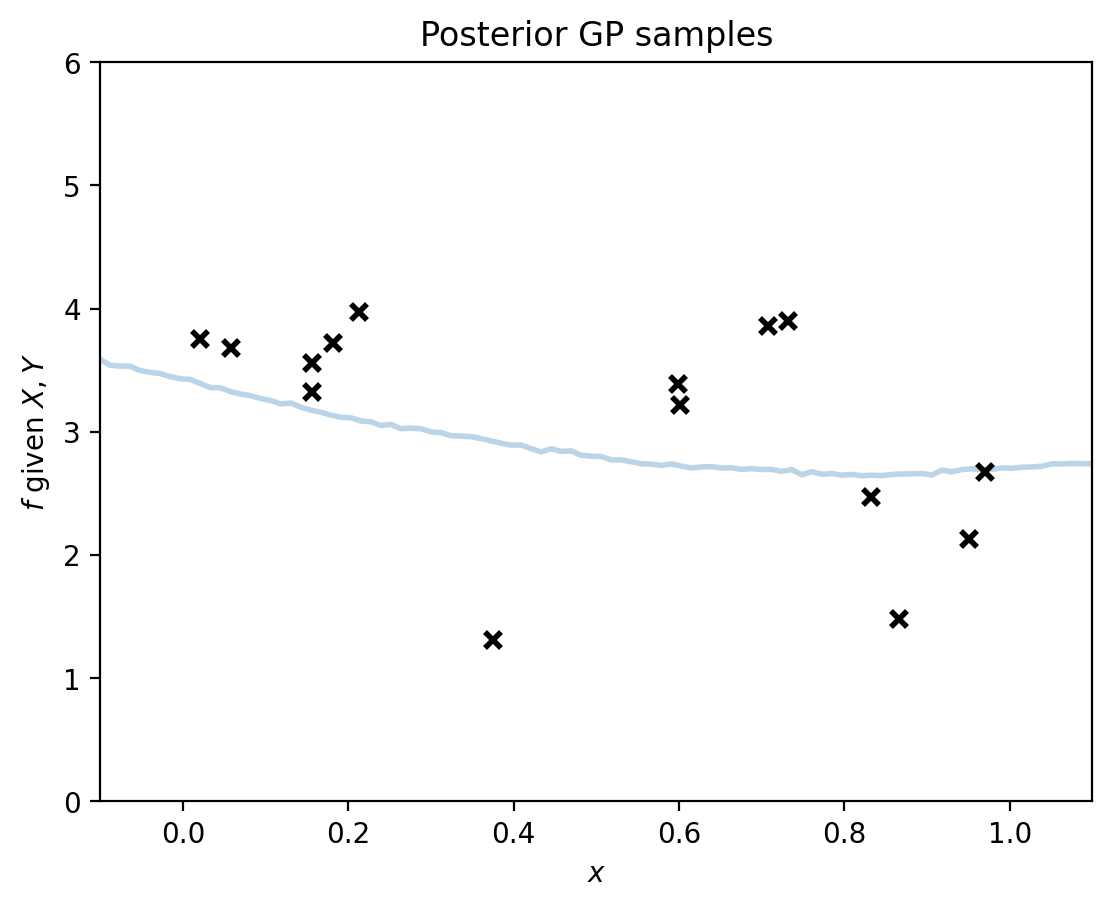

In [32]:
for var, var_samples in zip(hmc_helper.current_state, samples):
    var.assign(var_samples[8300])
f = model.predict_f_samples(xx, 1)
plt.plot(xx, f[0, :, :], "C0", lw=2, alpha=0.3)

plt.plot(X, Y, "kx", mew=2)
plt.xlim(xx.min(), xx.max())
plt.ylim(0, 6)
plt.xlabel("$x$")
plt.ylabel("$f$ given $X,Y$")
plt.title("Posterior GP samples")

plt.show()